Adds several regularization techniques to improve training performance without adding any new training data.
* Use dropout after maxpooling. [paper](https://arxiv.org/abs/1207.0580)
* Use batchnorm between conv and activation. [paper](https://arxiv.org/abs/1502.03167)
* Optionally add another VGG block (conv/bn/relu, conv/bn/relu, maxpooling). [paper](https://arxiv.org/abs/1409.1556)
* Increase the width of various blocks, like channels in the conv units.
* Augment the training data with minor rotate and scale
* Use a learning rate scheduler to reduce LR over time

With all changes, we get ~86.5%, up from under 70% in the baseline.

In [1]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as tvt
import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
class ScaleToUnit(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        x = x / 255.0
        return x

train_tfs = tvt.Compose([
    tvt.PILToTensor(),
    ScaleToUnit(),
    tvt.RandomHorizontalFlip(0.25),
    tvt.RandomAffine(
        degrees=5,
        scale=(0.9, 1.1),
    ),
])

val_tfs = tvt.Compose([
    tvt.PILToTensor(),
    ScaleToUnit(),
])

def transform(image):
    image = tvf.pil_to_tensor(image)
    image = image / 255
    return image

def onehot_label(cls: int):
    cls = torch.tensor(cls).long()
    return F.one_hot(cls, num_classes=11)

cifar_train = tds.CIFAR10(
    root='datasets',
    download=True,
    train=True,
    transform=train_tfs,
    target_transform=onehot_label,
)

cifar_eval = tds.CIFAR10(
    root='datasets',
    download=True,
    train=False,
    transform=val_tfs,
    target_transform=onehot_label,
)

Files already downloaded and verified
Files already downloaded and verified


In [3]:
batchsize = 128

train_loader = tud.DataLoader(cifar_train, batch_size=batchsize, shuffle=True)
val_loader = tud.DataLoader(cifar_eval, batch_size=batchsize, shuffle=True)

In [4]:
class MyCnn(nn.Module):
    def __init__(self, out_sz=10, ch=32):
        super().__init__()

        self.channels = ch
        self.out_sz = out_sz
        # (32x32)
        self.conv1_1 = nn.Conv2d(3, ch, kernel_size=3, stride=1, padding=1)
        self.bn1_1 = nn.BatchNorm2d(ch)
        self.conv1_2 = nn.Conv2d(ch, ch*2, kernel_size=3, stride=1, padding=1)
        self.bn1_2 = nn.BatchNorm2d(ch*2)

        # (16x16)
        self.conv2_1 = nn.Conv2d(ch*2, ch*2, kernel_size=3, stride=1, padding=1)
        self.bn2_1 = nn.BatchNorm2d(ch*2)
        self.conv2_2 = nn.Conv2d(ch*2, ch*4, kernel_size=3, stride=1, padding=1)
        self.bn2_2 = nn.BatchNorm2d(ch*4)
        
        # (8x8)
        self.conv3_1 = nn.Conv2d(ch*4, ch*4, kernel_size=3, stride=1, padding=1)
        self.bn3_1 = nn.BatchNorm2d(ch*4)
        self.conv3_2 = nn.Conv2d(ch*4, ch*8, kernel_size=3, stride=1, padding=1)
        self.bn3_2 = nn.BatchNorm2d(ch*8)
        
        self.lin1 = nn.Linear((ch*8) * 4 * 4, 512, bias=True)
        self.lin2 = nn.Linear(512, out_sz, bias=True)

    def forward(self, x):
        x = self.conv1_1(x)
        x = self.bn1_1(x)
        x = F.relu(x)
        x = self.conv1_2(x)
        x = self.bn1_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        x = F.dropout(x, p=0.1)

        x = self.conv2_1(x)
        x = self.bn2_1(x)
        x = F.relu(x)
        x = self.conv2_2(x)
        x = self.bn2_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        x = F.dropout(x, p=0.1)

        x = self.conv3_1(x)
        x = self.bn3_1(x)
        x = F.relu(x)
        x = self.conv3_2(x)
        x = self.bn3_2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.1)
        x = F.max_pool2d(x, kernel_size=2)
        
        x = x.view(-1, (self.channels*8) * 4 * 4)
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2)
        x = self.lin2(x)
        x = F.softmax(x, dim=-1)
        return x
        

In [5]:
from torchinfo import summary
testmodel = MyCnn(out_sz=11, ch=64)
summary(testmodel, (batchsize, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
MyCnn                                    [128, 11]                 --
├─Conv2d: 1-1                            [128, 64, 32, 32]         1,792
├─BatchNorm2d: 1-2                       [128, 64, 32, 32]         128
├─Conv2d: 1-3                            [128, 128, 32, 32]        73,856
├─BatchNorm2d: 1-4                       [128, 128, 32, 32]        256
├─Conv2d: 1-5                            [128, 128, 16, 16]        147,584
├─BatchNorm2d: 1-6                       [128, 128, 16, 16]        256
├─Conv2d: 1-7                            [128, 256, 16, 16]        295,168
├─BatchNorm2d: 1-8                       [128, 256, 16, 16]        512
├─Conv2d: 1-9                            [128, 256, 8, 8]          590,080
├─BatchNorm2d: 1-10                      [128, 256, 8, 8]          512
├─Conv2d: 1-11                           [128, 512, 8, 8]          1,180,160
├─BatchNorm2d: 1-12                      [128, 512,

2.039041042327881
1.976758360862732
1.8878930807113647
1.8901541233062744
1.8556534051895142
1.8407082557678223
1.8231871128082275
1.8032264709472656
1.7846262454986572
1.7869386672973633
1.7647979259490967
1.751855731010437
1.742995023727417
1.7400814294815063
1.7354732751846313
1.733328938484192
1.7284075021743774
1.726934552192688
1.72959566116333
1.727033019065857
1.8003982305526733
1.7675433158874512
1.8551104068756104
1.7611422538757324
1.7501680850982666
1.7507227659225464
1.7376117706298828
1.732493281364441
1.7296777963638306
1.7305608987808228
1.7132259607315063
1.708444356918335
1.7073242664337158
1.702215313911438
1.6993837356567383
1.6979721784591675
1.6959019899368286
1.6951286792755127
1.6957331895828247
1.6962348222732544
1.7389277219772339
1.746277093887329
1.7291297912597656
1.7525805234909058
1.716050148010254
1.7235671281814575
1.7378063201904297
1.715273141860962
1.7051793336868286
1.7022453546524048
1.6947908401489258
1.6945925951004028
1.685848355293274
1.6831378

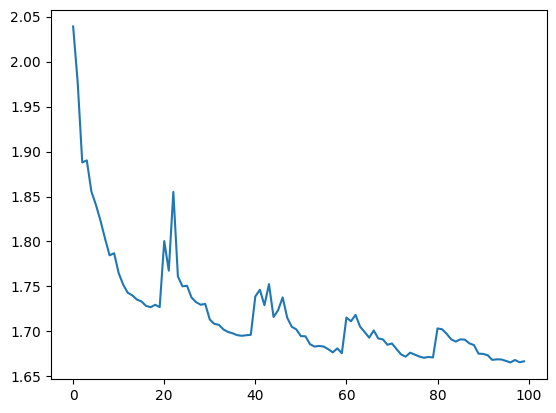

In [6]:
%%time
device='cuda'
model = MyCnn(out_sz=11, ch=32).to(device).train()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     'min',
#     patience=5,
#     verbose=True
# )
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=20,
    verbose=False,
)

lossfn = nn.CrossEntropyLoss()
epochs = 100

loss_plot = []
iters = len(train_loader)
for epoch in range(epochs):
    model.train()
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.float().to(device)

        outs = model(images)
        loss = lossfn(outs, targets.view(-1, 11))
        loss.backward()
        optimizer.step()
        cosine_scheduler.step(epoch + i / iters)

    losses = []
    model.eval()
    for i, (images, target) in enumerate(val_loader):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.float().to(device)
            outs = model(images)

            loss = lossfn(outs, targets.view(-1, 11))
            losses.append(loss)
                
    epoch_loss = torch.Tensor(losses).mean().item()
    print(epoch_loss)
    loss_plot.append(epoch_loss)
    # scheduler.step(epoch_loss)

plt.plot(loss_plot)

In [7]:
total = len(cifar_eval)
correct = 0
model.eval()
with torch.no_grad():
    for image, target in cifar_eval:
        pred = model(image.unsqueeze(0).float().to(device))
        if torch.allclose(pred.round().long().cpu(), target.cpu()):
            correct += 1
        
    print("{:.2f}% correct".format(100*correct/total))

87.71% correct
